In [624]:
import numpy as np
import pandas as pd

In [625]:
from pathlib import Path

DATA_DIR = Path("../data/")

metr_la = np.load(file= DATA_DIR/"metr_la_new.npz", allow_pickle=True)

In [626]:
start = 0
end = len(metr_la['targets'])
metr_la_target = metr_la["targets"][start : end]
for j in range(0, len(metr_la_target)):
    date = metr_la_target[j]
    for i in range(0, len(date)):
        if not isinstance(metr_la_target[j][i], int) and not (metr_la_target[j][i], float):
            metr_la_target[j][i] = metr_la_target[max(0, j - 1)][i]


In [627]:
ver_index = 0
frame = 50
shift =10

metr_la_target_ver = metr_la_target[:, ver_index]

local_maxes = []

for i in range(0, len(metr_la_target_ver) - frame):
    arg = (-1*metr_la_target_ver[i : i + frame]).argmax()
    if abs(arg - frame/2 )< shift:
        local_maxes.append(i + arg)

In [628]:
timestamps = pd.date_range(start=metr_la["first_timestamp_datetime"].item(),
                           end=metr_la["last_timestamp_datetime"].item(),
                           freq="5min",
                           )[start : end]

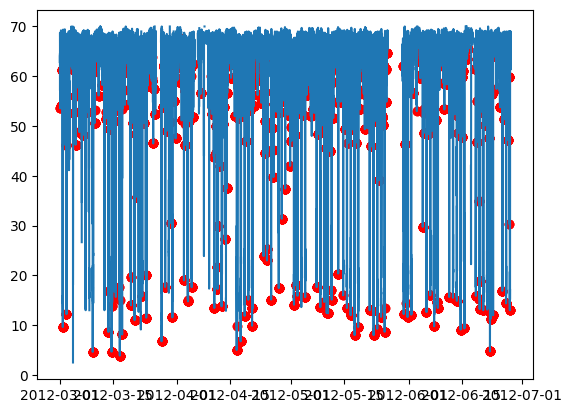

In [629]:
import matplotlib.pyplot as plt

plt.plot(timestamps, metr_la_target_ver)
plt.scatter(timestamps[local_maxes], metr_la_target_ver[local_maxes], color = 'r')

plt.show()

In [630]:
import torch

In [631]:
edges ={i : [] for i in range(0, len(metr_la["edges"]))} 
for elem in metr_la["edges"]:
    edges[elem[0]].append(elem[1])
    

In [632]:
data = [[metr_la_target[i][j] for j in edges[ver_index]] for i in range(0, len(metr_la_target))]
data = torch.tensor(data)
data

tensor([[60.7500, 55.7500, 67.1250, 59.7500, 66.7500],
        [64.3333, 60.8889, 68.4444, 61.3333, 64.2222],
        [64.8750, 62.3750, 64.0000, 60.8750, 68.0000],
        ...,
        [63.3333, 59.8889, 63.3333, 64.2222, 67.2222],
        [66.2500, 62.7500, 64.7500, 64.5000, 67.6250],
        [65.7778, 63.2222, 65.5556, 64.5556, 66.2222]])

In [633]:
train_size = 10000
x_train = data[:train_size ]
x_test = data[train_size :]
y_train = torch.tensor(metr_la_target[:, ver_index][:train_size])
y_test = torch.tensor(metr_la_target[:, ver_index][train_size:])

In [634]:
from torch.utils.data import DataLoader, TensorDataset
import os

dataset = TensorDataset(x_train, y_train)
dataloader = DataLoader(dataset=dataset,
                        batch_size = 16,
                        shuffle = True,
                        num_workers = os.cpu_count())

In [635]:
from torch import nn

layer1 = nn.Linear(len(edges[ver_index]), 1024) 
layer2 = nn.Linear(1024, 1)

model = nn.Sequential(layer1, nn.ReLU(), layer2, nn.ReLU())

In [636]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)
loss_fn = nn.L1Loss()

In [637]:
from tqdm.auto import tqdm

In [638]:
# losses = []
# for epoch in tqdm(range(100)):
#     for batch_X, batch_Y in dataloader:
#         Y_pred = model(batch_X)
#         loss = loss_fn(Y_pred, batch_Y)
#         losses.append(loss.item())
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

In [639]:
# plt.plot(np.array([loss.item() for loss in losses]))

In [640]:
" new approach "
barier = 20

def traffic_jams(ver:int, st: int, en:int, jams = None):
    jams = jams or []
    time_sery = metr_la["targets"][st : en, ver]
    plt.plot(time_sery)
    status = False
    jam =[]
    for i in range(0, len(time_sery)):
        if status:
            jam.append(i)
        if time_sery[i] <= barier:
            status = True
        if time_sery[i] > barier:
            status = False
            jams.append(jam)
            jam = []
    for elem in jams:
        plt.plot(elem, time_sery[elem], color = 'r')
        print(len(elem) * 5)



    

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
80
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
5
0
5
10
0
5
50
10
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


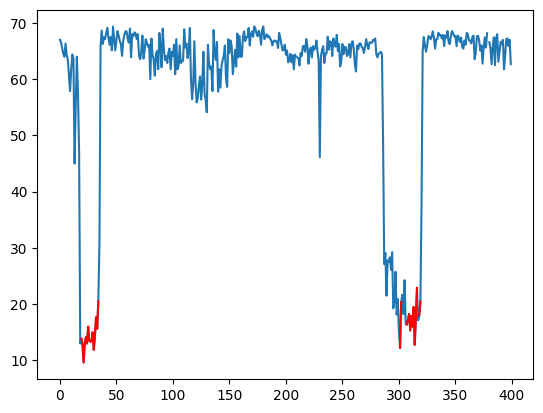

In [641]:
traffic_jams(0, 200, 600)

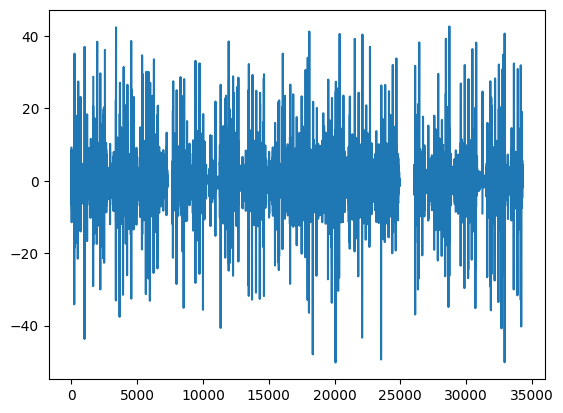

In [642]:
delta_metr_la_target = metr_la_target[1:, ver_index]-metr_la_target[:-1, ver_index]
plt.plot(delta_metr_la_target)

In [643]:
timestamps = pd.date_range(start=metr_la["first_timestamp_datetime"].item(),
                           end=metr_la["last_timestamp_datetime"].item(),
                           freq="5min",
                           )


ver_index = 5
start = 0
end = len(metr_la['targets'])
print(end)

def distr_of_jams(ver):
    distribution = np.array([0] * 288)
    for i in range(start, end):
        if metr_la_target[i][ver] < 15:
            timestamp_cur = timestamps[i]
            min_cur = timestamp_cur.hour * 60 + timestamp_cur.minute
            distribution[min_cur//5]+=1
    return distribution

34272


In [644]:
import random

In [648]:
import plotly.express as px 
px.line(x = [i * 5 / 60 for i in range(0, 288)], 
        y = [np.array(distr_of_jams(random.randint(0, 200))) for k in range(0, 10)])


In [646]:
def average_distr_of_jams():
    distribution = np.array([0] * 288)
    for i in range(0, 207):
        distribution = distribution + distr_of_jams(i)
    return distribution / 207

px.line(x = [i * 5 / 60 for i in range(0, 288)], 
        y = average_distr_of_jams())
